In [1]:
PATH_WORK_DIR = ".."

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M2-PJT_TXT


In [4]:
import sys
sys.path.append("src")

# packages

In [ ]:
from pathlib import Path
import pickle
import arviz as az
import matplotlib.pyplot as plt
from pymyproject.bcpd import analysis

# data

In [11]:
PATH = "./result/factor/scores.pkl"
with open(file=PATH, mode="rb") as f:
    scores = pickle.load(f)

In [12]:
FACTOR = 2
PATH = f"./result/bcpd/f{FACTOR}/"
folder = Path(PATH)

trace = dict()

for i, PATH in enumerate(folder.glob("*.nc")):
    with open(file=PATH, mode="rb") as f:
        trace[i+1] = az.from_netcdf(PATH)

# convergence diagnostics

## N_CPS==1

In [13]:
N_CPS = 1
data = trace[N_CPS]

In [14]:
summary = az.summary(data=data)

COND1 = summary["ess_bulk"]<400
COND2 = summary["ess_tail"]<400
COND3 = summary["r_hat"]>1.01
COND4 = summary.index.str.contains("tau_raw")
summary[(COND1 | COND2 | COND3) & (~COND4)]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mus[1],-0.669,0.070,-0.808,-0.546,0.004,0.001,350.0,1531.0,1.01
tau[0],470.119,18.004,451.000,496.000,1.561,0.464,187.0,840.0,1.02


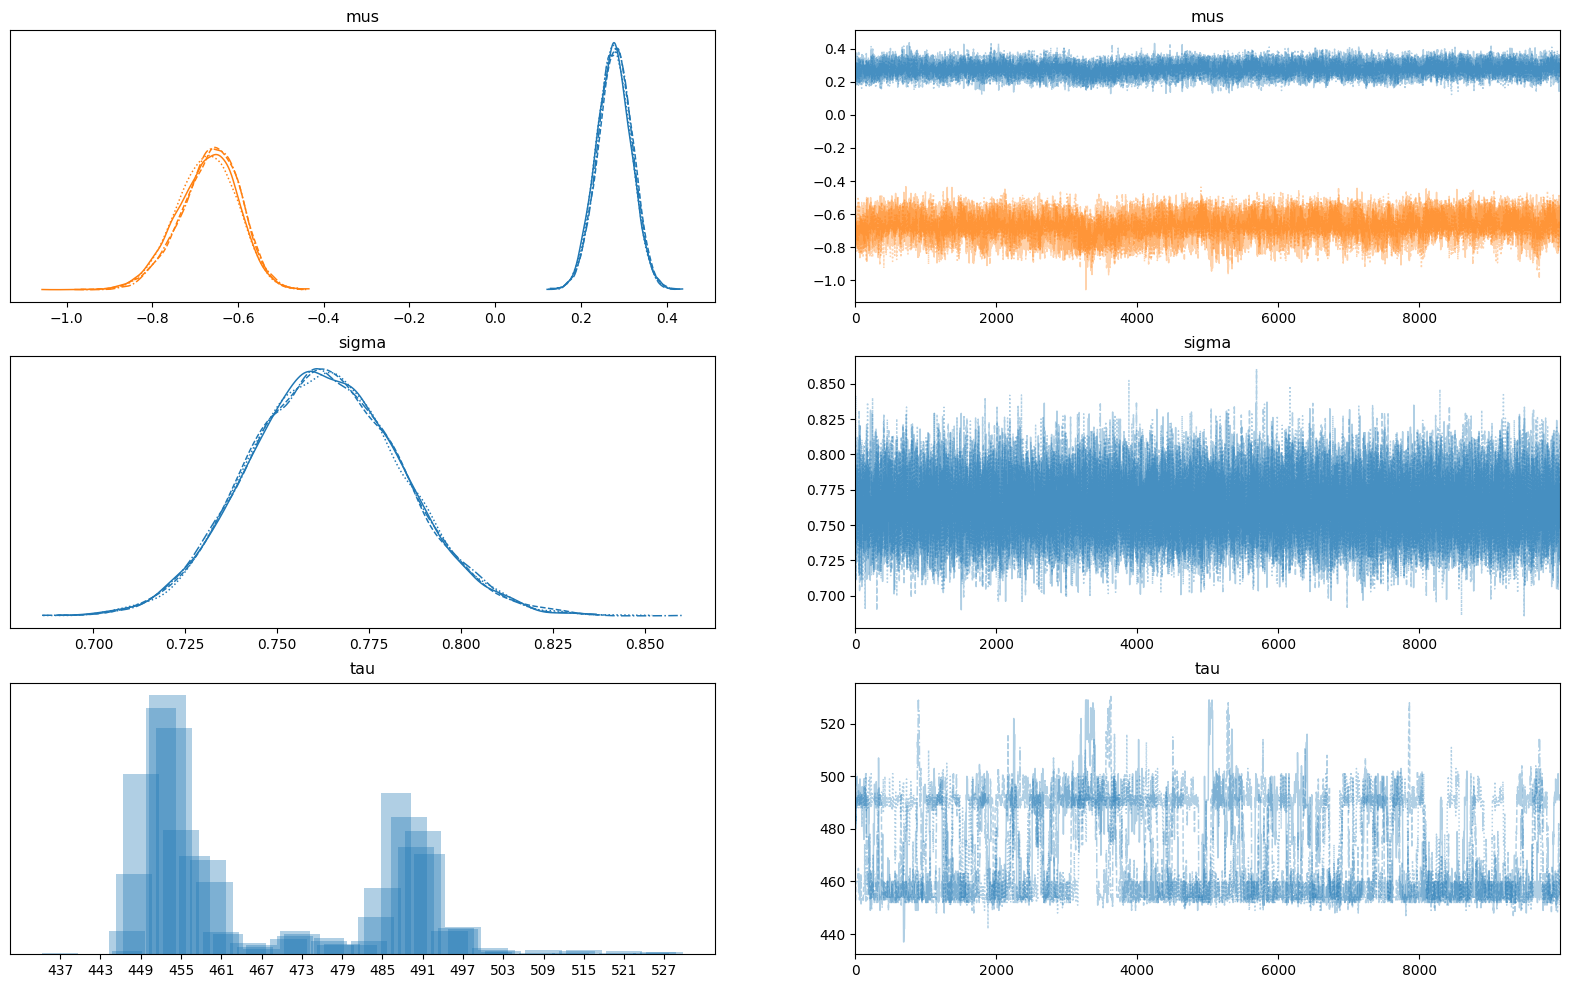

In [15]:
exclude = {"tau_raw"}

var_names = [
    name for name in data.posterior.data_vars
    if name not in exclude
]

kwargs = dict(
    data=data, 
    var_names=var_names, 
    figsize=(20,12),
)

az.plot_trace(**kwargs)
plt.show()

## N_CPS==2

In [16]:
N_CPS = 2
data = trace[N_CPS]

In [17]:
summary = az.summary(data=data)

COND1 = summary["ess_bulk"]<400
COND2 = summary["ess_tail"]<400
COND3 = summary["r_hat"]>1.01
COND4 = summary.index.str.contains("tau_raw")
summary[(COND1 | COND2 | COND3) & (~COND4)]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat


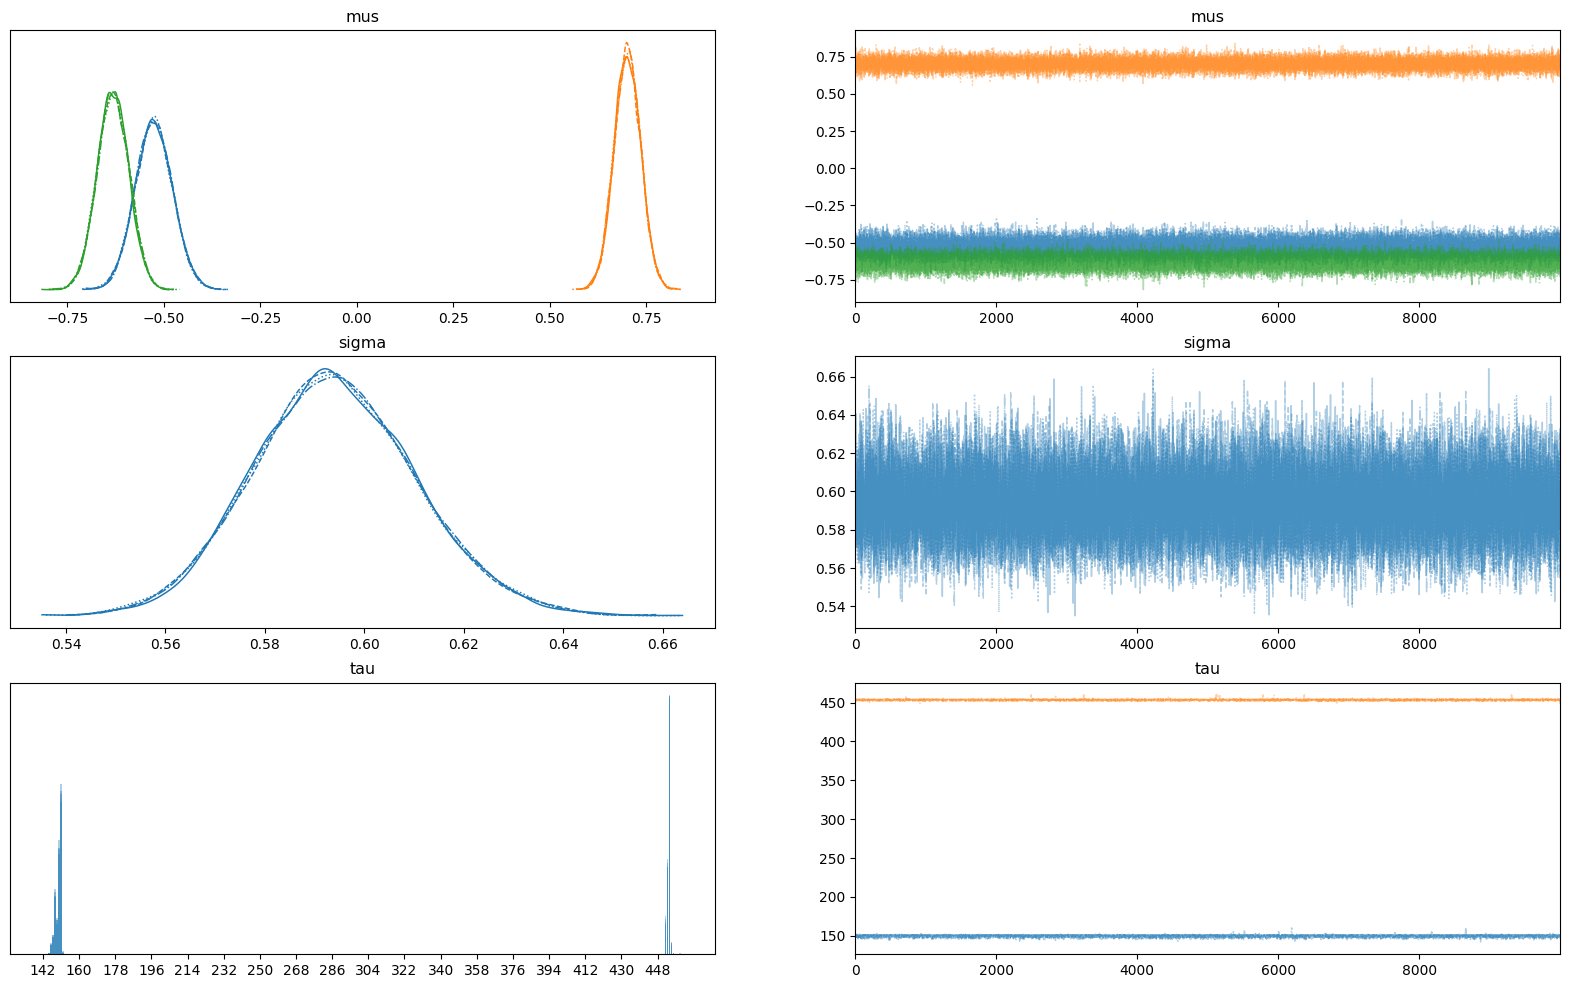

In [18]:
exclude = {"tau_raw"}

var_names = [
    name for name in data.posterior.data_vars
    if name not in exclude
]

kwargs = dict(
    data=data, 
    var_names=var_names, 
    figsize=(20,12),
)

az.plot_trace(**kwargs)
plt.show()

## N_CPS==3

In [19]:
N_CPS = 3
data = trace[N_CPS]

In [20]:
summary = az.summary(data=data)

COND1 = summary["ess_bulk"]<400
COND2 = summary["ess_tail"]<400
COND3 = summary["r_hat"]>1.01
COND4 = summary.index.str.contains("tau_raw")
summary[(COND1 | COND2 | COND3) & (~COND4)]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mus[1],0.600,0.170,0.348,0.826,0.081,0.000,6.0,87.0,1.73
mus[2],0.371,0.540,-0.252,0.987,0.269,0.001,6.0,87.0,1.73
mus[3],-0.685,0.146,-0.894,-0.481,0.070,0.000,6.0,86.0,1.73
sigma,0.575,0.018,0.541,0.608,0.004,0.000,17.0,144.0,1.14
tau[0],149.169,1.950,146.000,151.000,0.445,0.134,20.0,55.0,1.13
tau[1],332.451,93.162,228.000,427.000,46.436,0.115,6.0,88.0,1.76
tau[2],477.177,51.362,424.000,529.000,25.612,0.182,6.0,10.0,1.88


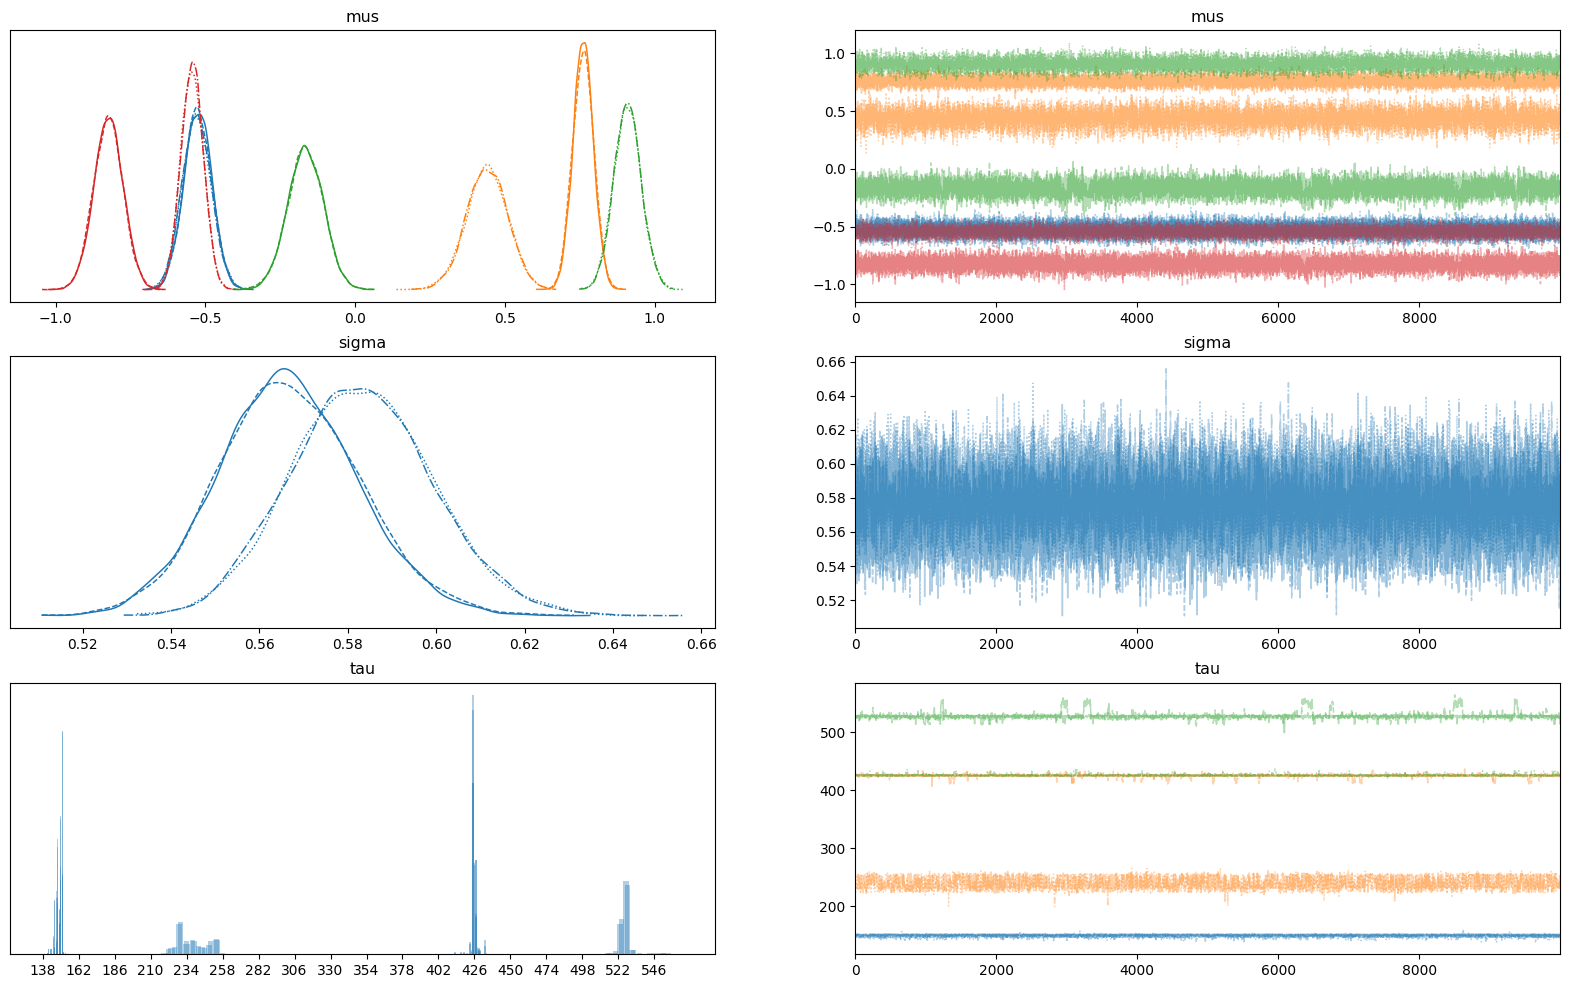

In [21]:
exclude = {"tau_raw"}

var_names = [
    name for name in data.posterior.data_vars
    if name not in exclude
]

kwargs = dict(
    data=data, 
    var_names=var_names, 
    figsize=(20,12),
)

az.plot_trace(**kwargs)
plt.show()

## N_CPS==4

In [22]:
N_CPS = 4
data = trace[N_CPS]

In [23]:
summary = az.summary(data=data)

COND1 = summary["ess_bulk"]<400
COND2 = summary["ess_tail"]<400
COND3 = summary["r_hat"]>1.01
COND4 = summary.index.str.contains("tau_raw")
summary[(COND1 | COND2 | COND3) & (~COND4)]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mus[1],0.521,0.152,0.332,0.810,0.070,0.036,7.0,25.0,1.53
mus[2],0.665,0.446,-0.215,1.003,0.218,0.130,7.0,26.0,1.53
mus[3],-0.279,0.236,-0.787,-0.039,0.105,0.069,8.0,27.0,1.47
mus[4],-0.879,0.130,-1.188,-0.719,0.047,0.038,11.0,27.0,1.27
sigma,0.553,0.017,0.522,0.584,0.003,0.000,30.0,104.0,1.08
tau[0],148.859,1.951,146.000,151.000,0.351,0.022,30.0,181.0,1.09
tau[1],285.961,79.703,229.000,427.000,39.601,22.651,7.0,38.0,1.54
tau[2],445.645,41.011,414.000,529.000,19.162,12.528,7.0,158.0,1.74
tau[3],549.044,41.684,523.000,642.000,17.666,13.250,9.0,45.0,1.43


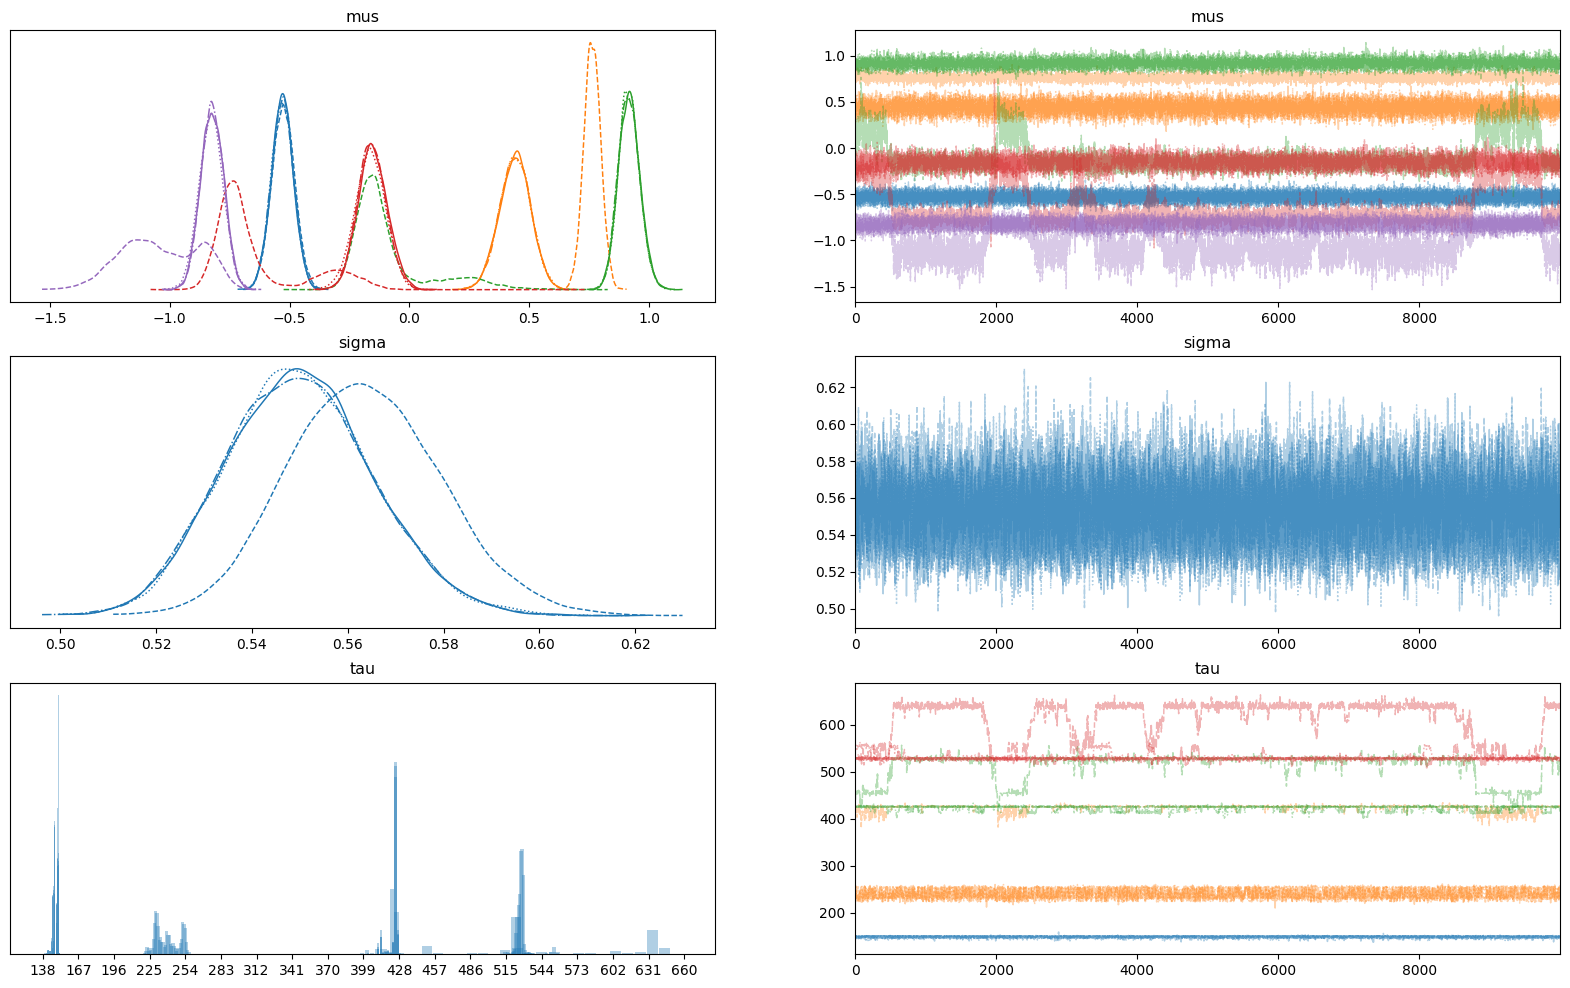

In [24]:
exclude = {"tau_raw"}

var_names = [
    name for name in data.posterior.data_vars
    if name not in exclude
]

kwargs = dict(
    data=data, 
    var_names=var_names, 
    figsize=(20,12),
)

az.plot_trace(**kwargs)
plt.show()

## N_CPS==5

In [25]:
N_CPS = 5
data = trace[N_CPS]

In [26]:
summary = az.summary(data=data)

COND1 = summary["ess_bulk"]<400
COND2 = summary["ess_tail"]<400
COND3 = summary["r_hat"]>1.01
COND4 = summary.index.str.contains("tau_raw")
summary[(COND1 | COND2 | COND3) & (~COND4)]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau[4],528.384,4.47,521.0,532.0,0.245,0.631,1096.0,368.0,1.0


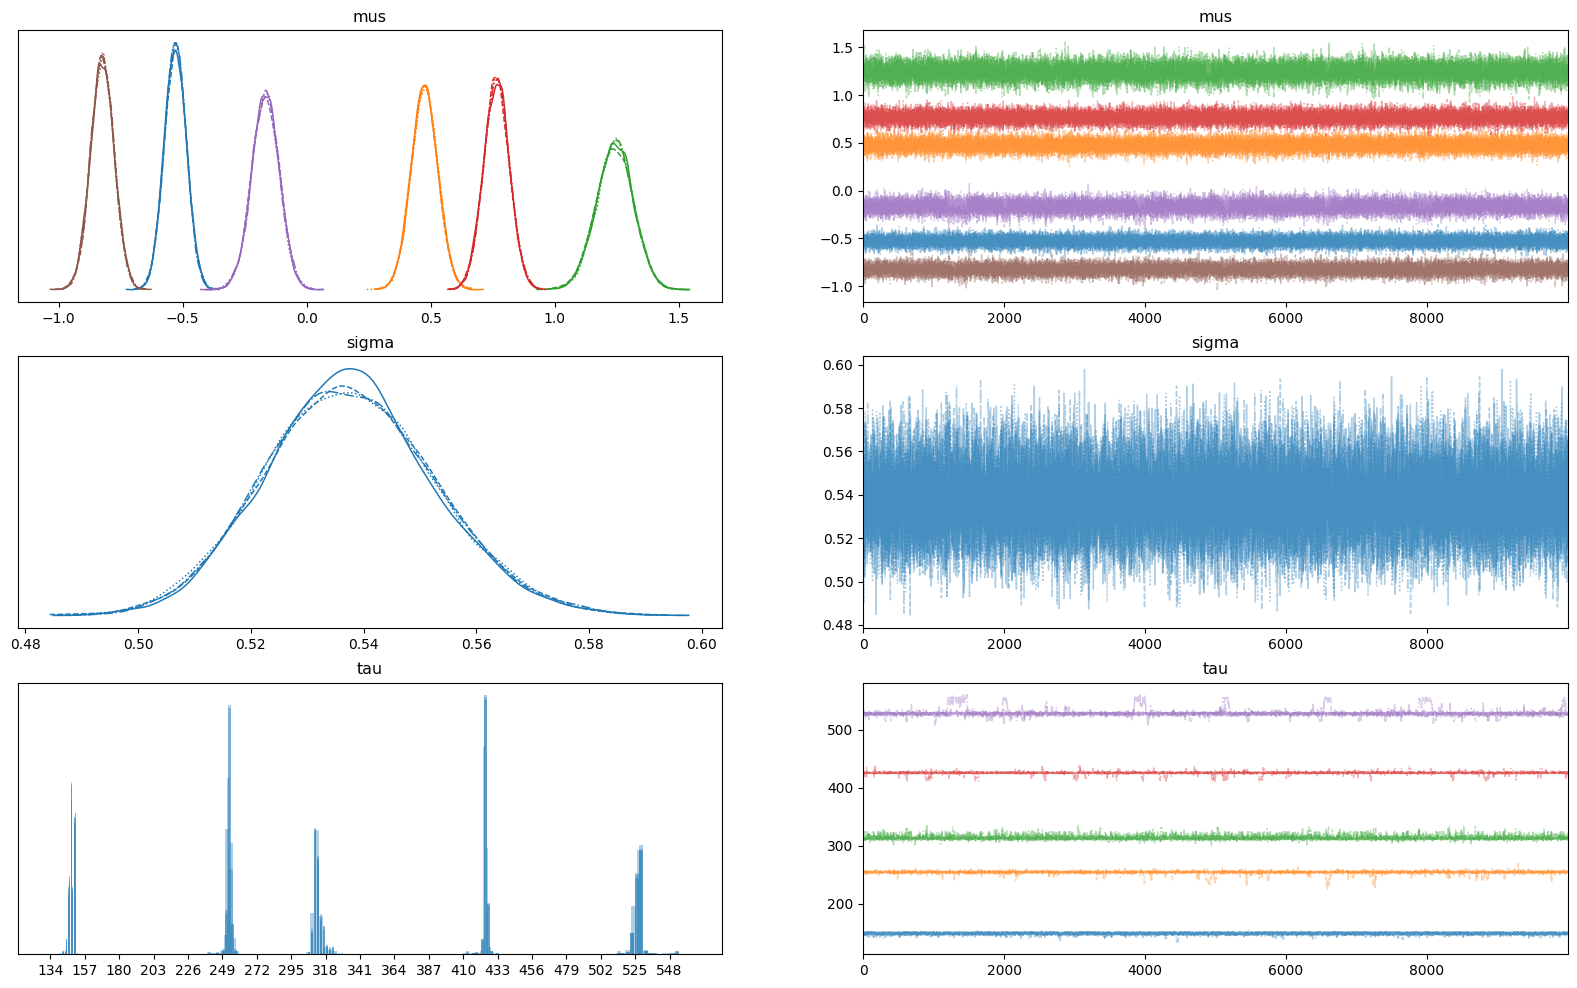

In [27]:
exclude = {"tau_raw"}

var_names = [
    name for name in data.posterior.data_vars
    if name not in exclude
]

kwargs = dict(
    data=data, 
    var_names=var_names, 
    figsize=(20,12),
)

az.plot_trace(**kwargs)
plt.show()

# ppc

In [28]:
IC = "loo"

compare_dict = {
    f"cps{k}": obj
    for k, obj in trace.items()
}

kwargs = dict(
    compare_dict=compare_dict,
    ic=IC,
)
cmp = az.compare(**kwargs)

In [29]:
cmp

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
cps5,0,-539.322978,15.150257,0.000000,0.85272,18.446015,0.000000,True,log
cps4,1,-563.137354,25.497142,23.814376,0.00000,18.425081,6.959243,True,log
cps3,2,-594.063665,35.595152,54.740687,0.00000,18.508286,8.646594,True,log
cps2,3,-600.674539,5.527227,61.351561,0.14728,17.754797,14.227179,True,log
cps1,4,-768.998267,8.944969,229.675289,0.00000,16.349351,18.173899,True,log


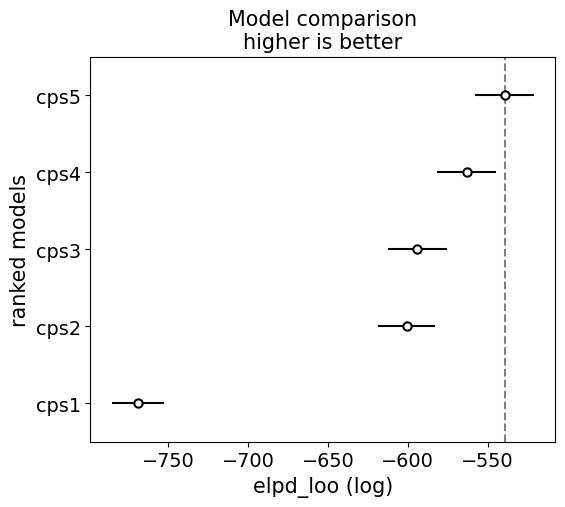

In [30]:
az.plot_compare(cmp)
plt.show()

# change point

## N_CPS==2

In [31]:
FACTOR = 2
N_CPS = 2
TRACE = trace[N_CPS]

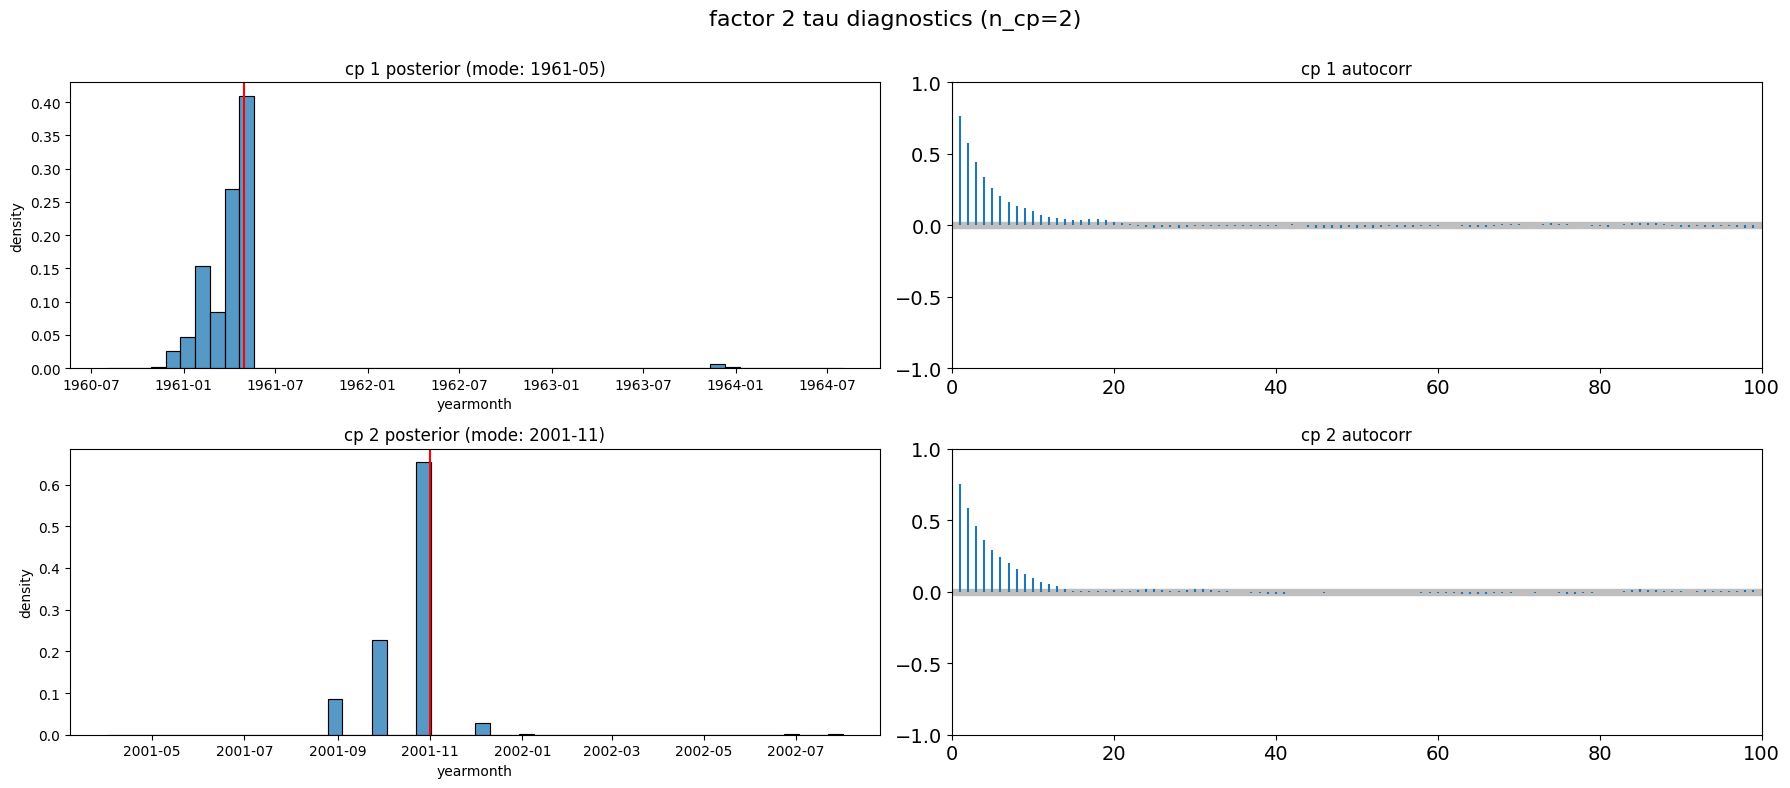

In [32]:
DATE = doc_topic_mat.index.to_timestamp()

kwargs = dict(
    trace=TRACE,
    date=DATE,
    factor=FACTOR,
)

analysis.posterior.main(**kwargs)

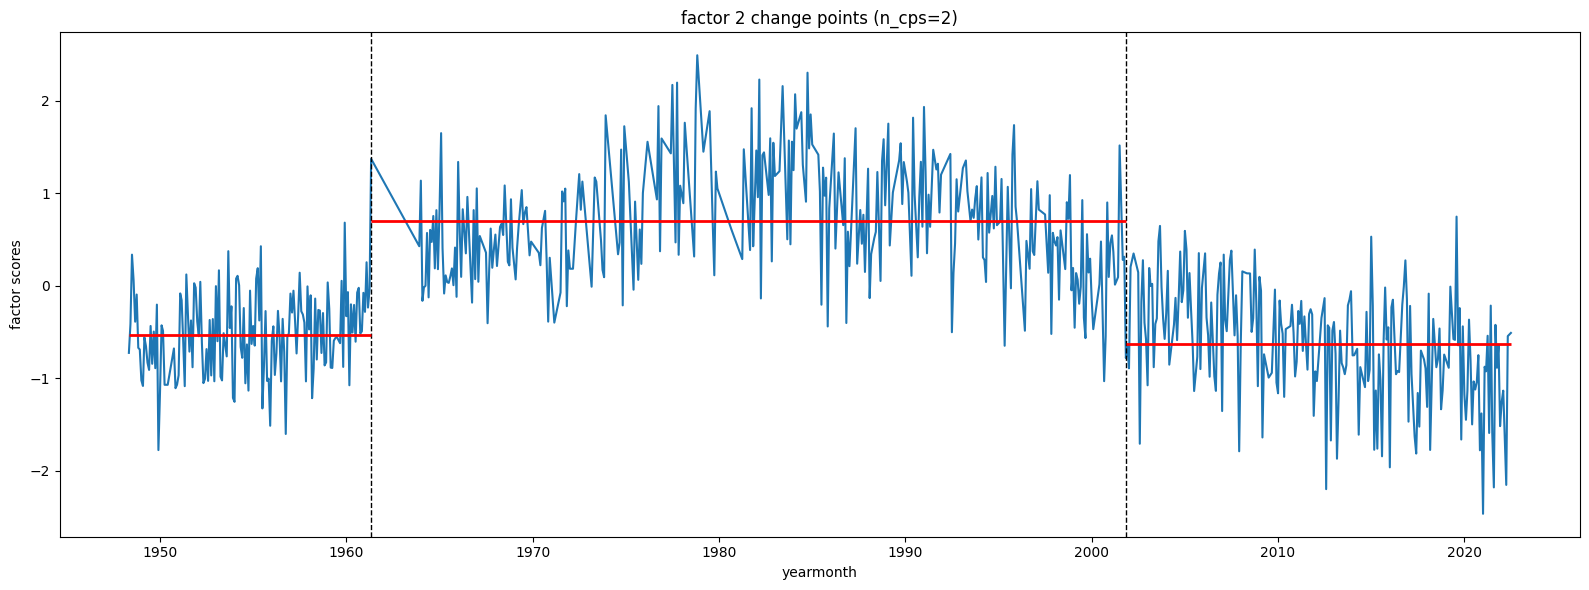

In [33]:
FIGSIZE = (16,6)

kwargs = dict(
    trace=TRACE,
    scores=scores,
    factor=FACTOR,
    figsize=FIGSIZE,
)

analysis.changepoint.main(**kwargs)

## N_CPS==5

In [35]:
FACTOR = 2
N_CPS = 5
TRACE = trace[N_CPS]

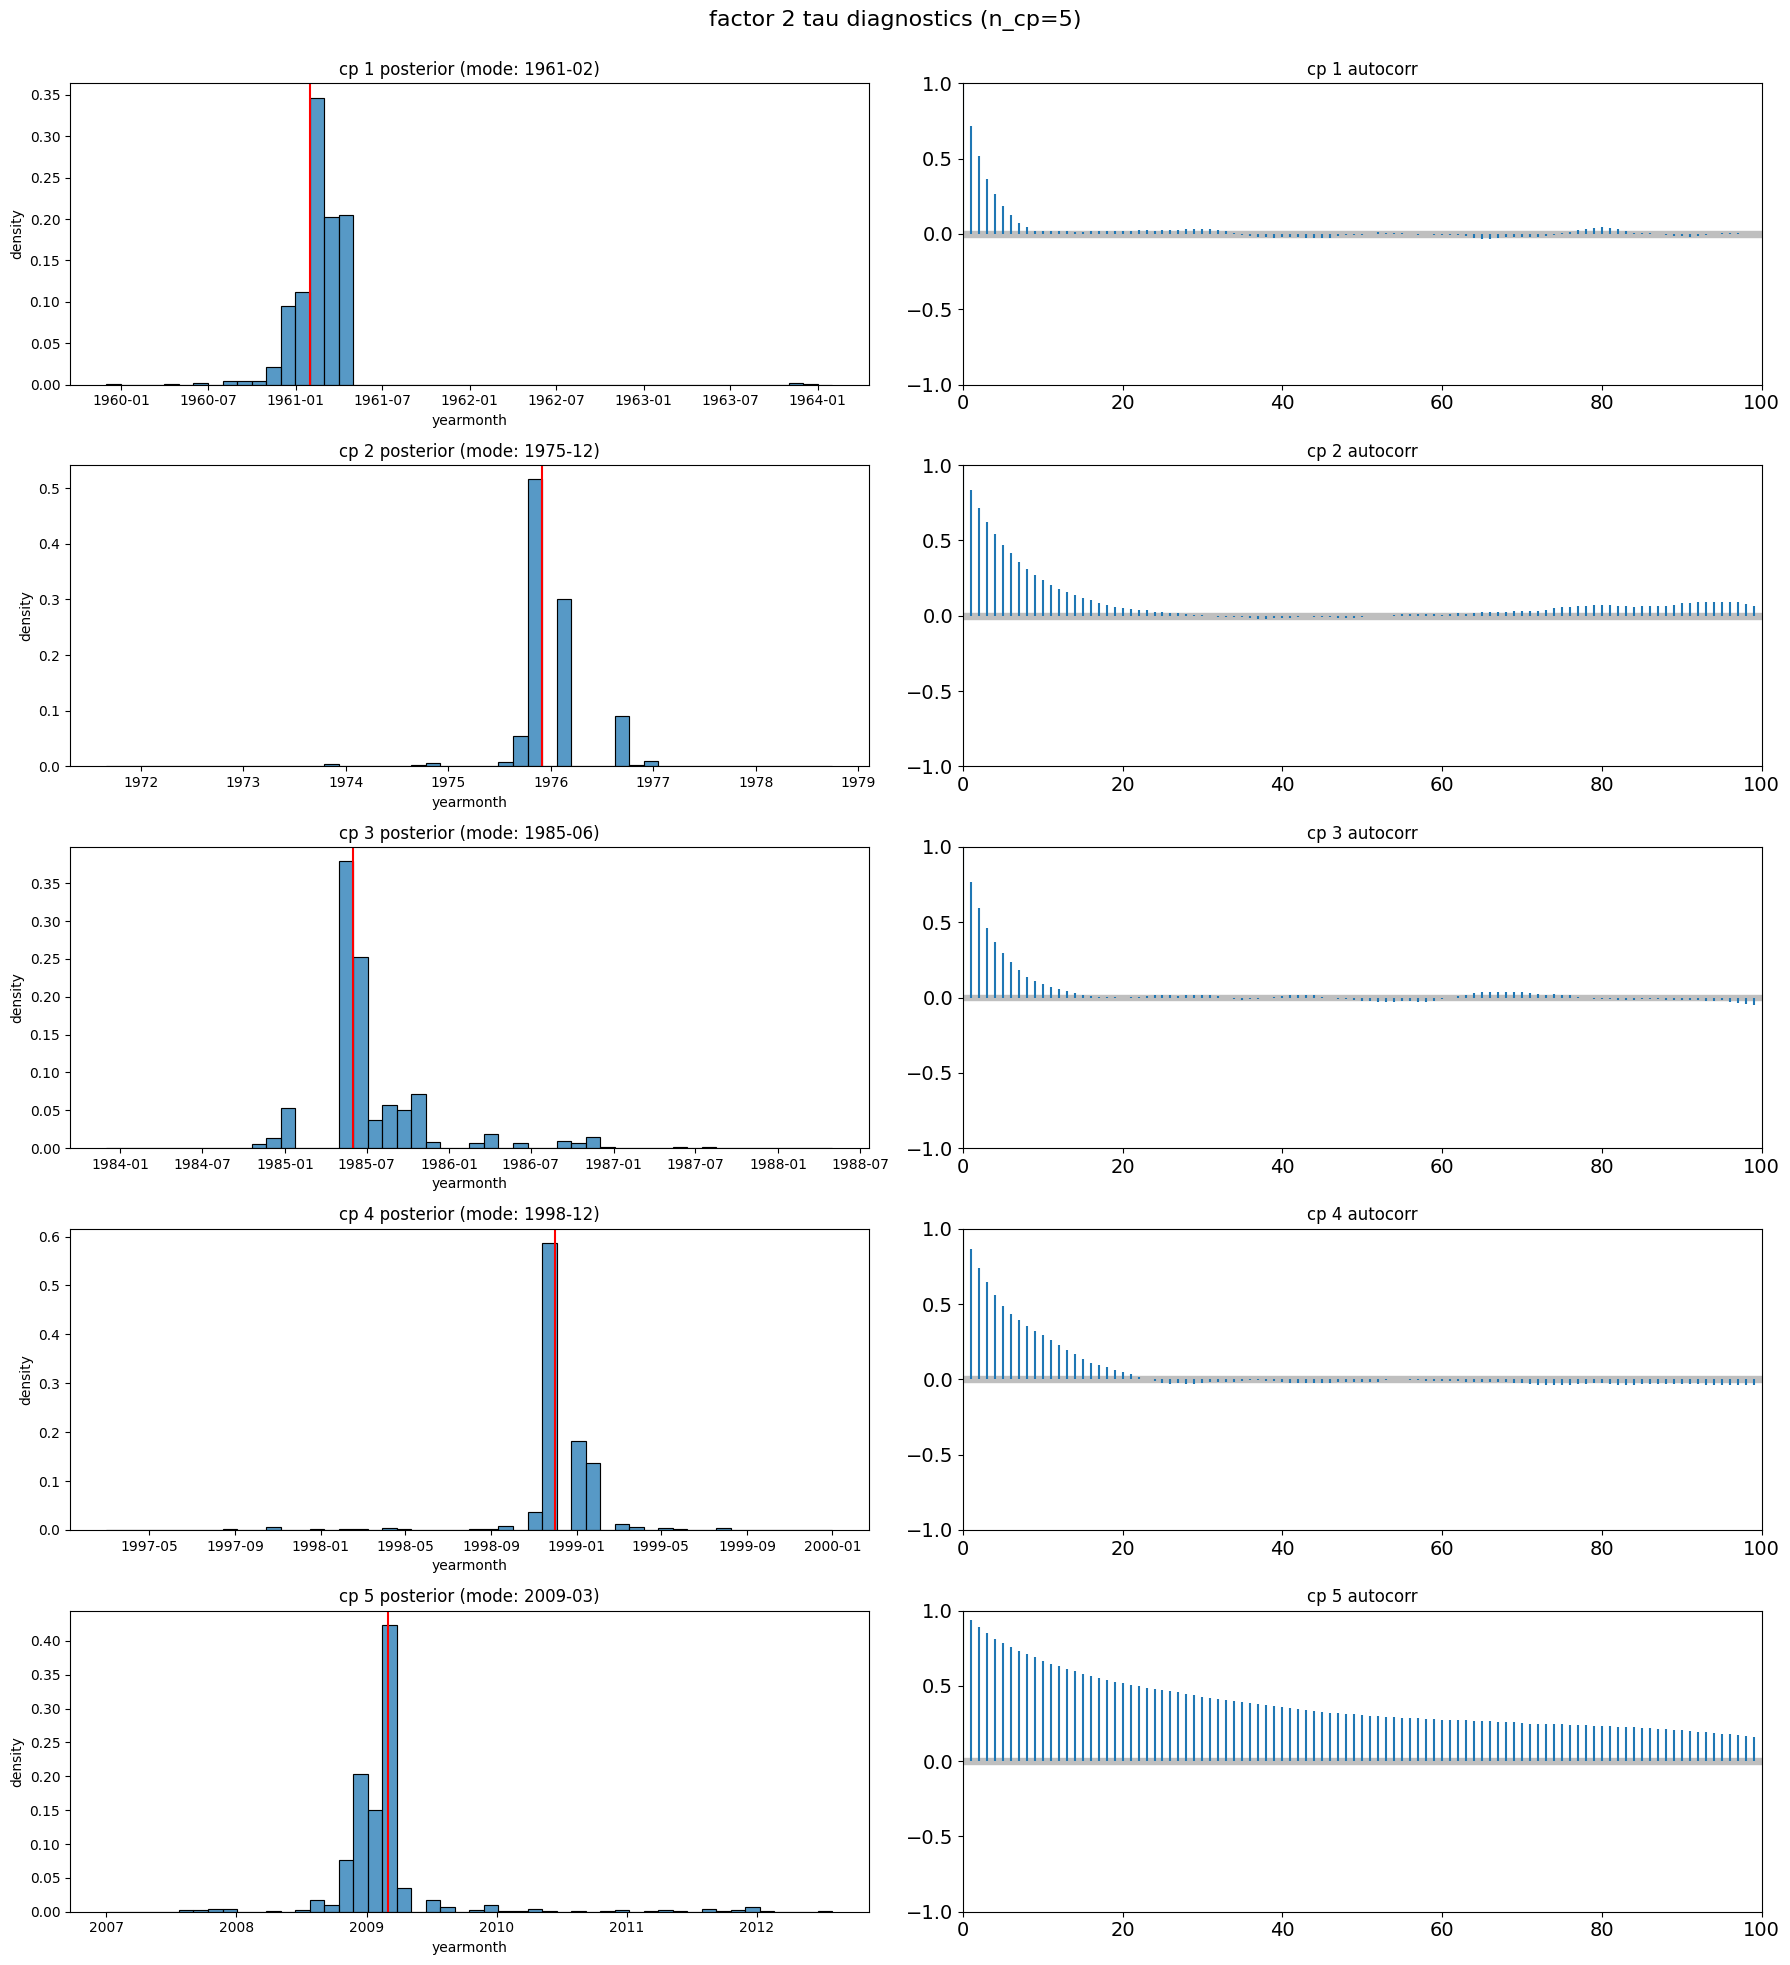

In [ ]:
DATE = scores.index.to_timestamp()

kwargs = dict(
    trace=TRACE,
    date=DATE,
    factor=FACTOR,
)

analysis.posterior.main(**kwargs)

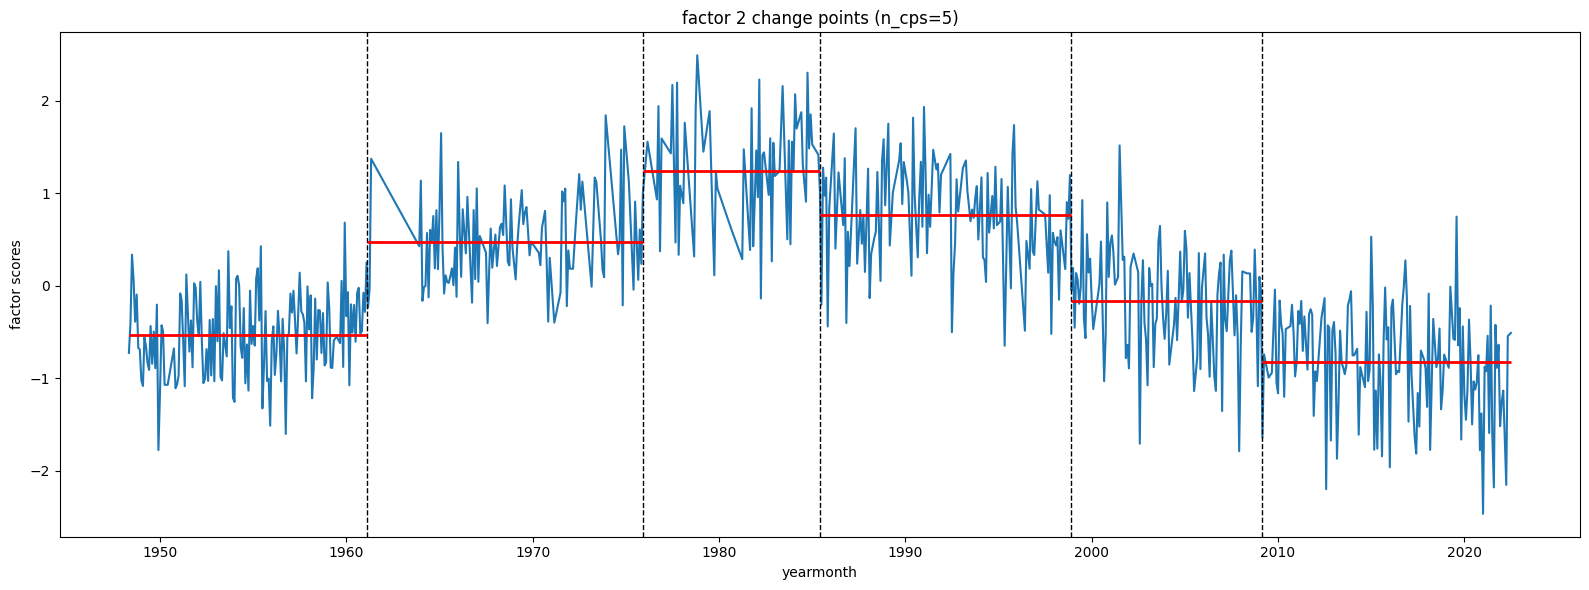

In [37]:
FIGSIZE = (16,6)

kwargs = dict(
    trace=TRACE,
    scores=scores,
    factor=FACTOR,
    figsize=FIGSIZE,
)

analysis.changepoint.main(**kwargs)